In [1]:
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.colors as col
from sklearn.metrics import r2_score


import cartopy.crs as ccrs
import pyproj
import csv
import netCDF4 as nc

import rasterio
from rasterio.plot import show

from scipy.signal import convolve2d
import datetime as dt

import helpers

(301, 301)
(301, 301)
[3910061. 3910161. 3910261. 3910361. 3910461. 3910561. 3910661. 3910761.
 3910861. 3910961. 3911061. 3911161. 3911261. 3911361. 3911461. 3911561.
 3911661. 3911761. 3911861. 3911961. 3912061. 3912161. 3912261. 3912361.
 3912461. 3912561. 3912661. 3912761. 3912861. 3912961. 3913061. 3913161.
 3913261. 3913361. 3913461. 3913561. 3913661. 3913761. 3913861. 3913961.
 3914061. 3914161. 3914261. 3914361. 3914461. 3914561. 3914661. 3914761.
 3914861. 3914961. 3915061. 3915161. 3915261. 3915361. 3915461. 3915561.
 3915661. 3915761. 3915861. 3915961. 3916061. 3916161. 3916261. 3916361.
 3916461. 3916561. 3916661. 3916761. 3916861. 3916961. 3917061. 3917161.
 3917261. 3917361. 3917461. 3917561. 3917661. 3917761. 3917861. 3917961.
 3918061. 3918161. 3918261. 3918361. 3918461. 3918561. 3918661. 3918761.
 3918861. 3918961. 3919061. 3919161. 3919261. 3919361. 3919461. 3919561.
 3919661. 3919761. 3919861. 3919961. 3920061. 3920161. 3920261. 3920361.
 3920461. 3920561. 3920661. 3

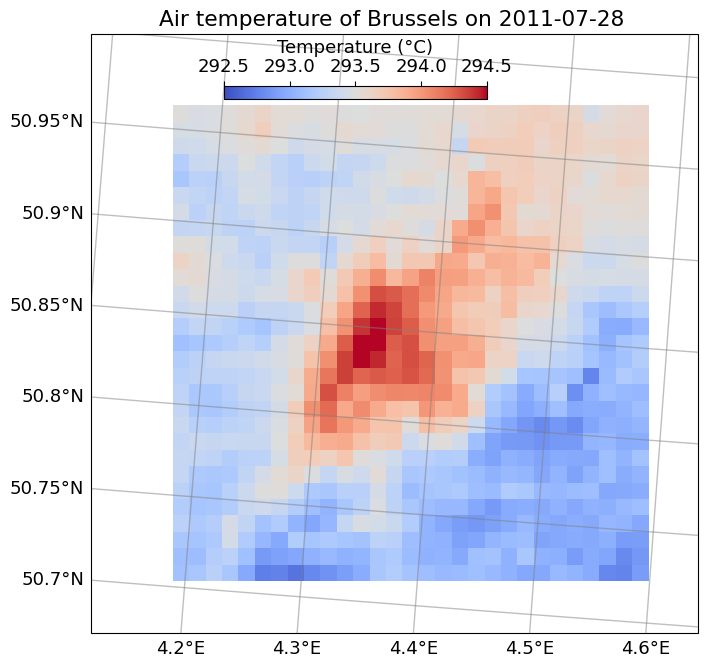

In [33]:

# Open the netCDF file
year = '2011'
month = '07'
date = '28'
hour = '14'
ncfile5 = nc.Dataset('./data/Meteorology/Brussels/Air_temp_brussels/tas_Brussels_UrbClim_'+year+'_'+month+'_v1.0.nc',mode='r',format='NETCDF4_CLASSIC') 


step, print_date = helpers.find_step(year, month, date, hour)
# Extract the latitude and longitude coordinates from the file
lons = ncfile5.variables['longitude'][:]
lats = ncfile5.variables['latitude'][:]
data = ncfile5.variables['tas'][step,:,:]
x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]

print(lons.shape)
print(lats.shape)
print(x)
print(y)
print(data.shape)
extent_4326 = [lons.min(), lons.max(), lats.min(), lats.max()]
extent_3035 = [y.min(), y.max(), x.min(), x.max() ]

print('extent_4326: ',extent_4326)
print('extent_3035: ',extent_3035)
clip_3035, clip, y_int, x_int = helpers.clip_city(extent_3035, extent_3035, 100)
print('clip_3035, clip, y_int, x_int', clip_3035, clip, y_int, x_int)
data2 = data[clip[0]:clip[1], clip[2]:clip[3]]
extent_4326 = helpers.get_extent(clip_3035,3035,4326)

sif_feat_lr = helpers.up_scale(data2, SCALE_FACTOR=10)
print(sif_feat_lr.shape)

Ys, Xs = helpers.GetCentroids(yLims=[clip_3035[0], clip_3035[1]], xLims=[clip_3035[2], clip_3035[3]], shapeYX=(y_int, x_int))
# Plot the data using pcolormesh

# Create a plot with the correct coordinate system
plt.figure(figsize=(8.48, 9.15))
plt.rcParams.update({'font.size': 13})
ax = plt.axes(projection=ccrs.epsg(3035))

# Plot the data using pcolormesh
plt.pcolormesh(Xs, Ys, sif_feat_lr, cmap='coolwarm', vmin=292.5, vmax=294.5)  #
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Set plot title
plt.title('Air temperature of Brussels on ' + print_date)

# Show the plot
plt.colorbar(label='Temperature (°C)',location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.7))


#plt.savefig('./data/Temp.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()
# Close the NetCDF file
ncfile5.close()

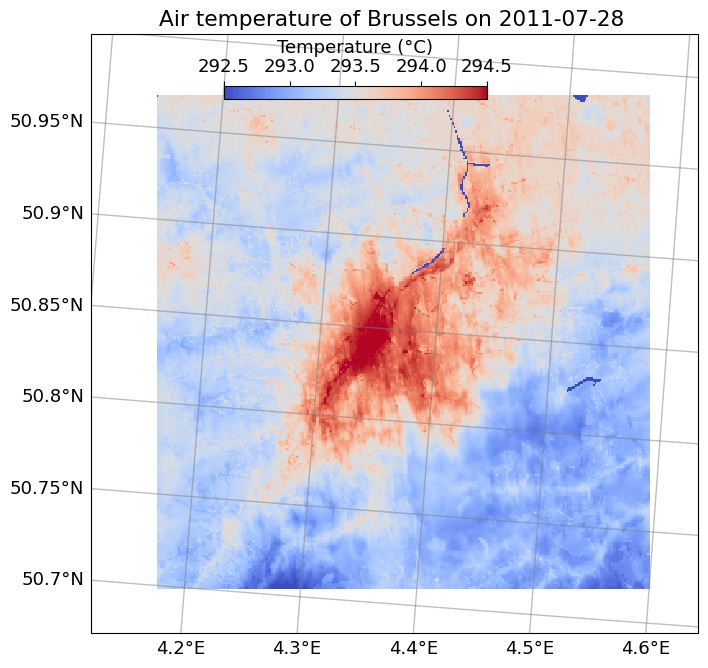

In [58]:


# Open the NetCDF file
ncfile5 = nc.Dataset('./data/Meteorology/Brussels/Air_temp_brussels/tas_Brussels_UrbClim_2011_07_v1.0.nc', mode='r', format='NETCDF4_CLASSIC')

# Extract the latitude, longitude, and temperature data from the file
lons = ncfile5.variables['longitude'][:]
lats = ncfile5.variables['latitude'][:]
data = ncfile5.variables['tas'][step,:, :]
x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]

# Create a plot with the correct coordinate system
plt.figure(figsize=(8.48, 9.15))
plt.rcParams.update({'font.size': 13})
ax = plt.axes(projection=ccrs.epsg(3035))

# Plot the data using pcolormesh
plt.pcolormesh(x, y, data, cmap='coolwarm', vmin=292.5, vmax=294.5)
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Set plot title
plt.title('Air temperature of Brussels on ' + print_date)

# Show the plot
plt.colorbar(label='Temperature (°C)',location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.7))


#plt.savefig('./data/Temp.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()
# Close the NetCDF file
ncfile5.close()

In [59]:
#PRODUCE NC FILE
year = '2013'

item = 0 #0=Air_temp, 1=RH, 2=Wind
folder = ['Air_temp_brussels', 'Relative_humidity_brussels', 'Wind_speed_brussels']
file = ['tas', 'russ', 'sfcWind']
output = ['Air_temp', 'RH', 'Wind']
ncfile5 = nc.Dataset('./data/Meteorology/Brussels/Air_temp_brussels/tas_Brussels_UrbClim_'+year+'_'+month+'_v1.0.nc',mode='r',format='NETCDF4_CLASSIC') 

x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]

extent_meteo = [y.min(), y.max(), x.min(), x.max() ]

print('extent_meteo: ',extent_meteo)
ncfile5.close()


clip_3035, clip, y_int, x_int = helpers.clip_city(extent_meteo, extent_meteo, 50) 

print('clip_3035',clip_3035)
print('clip_3035',clip)
#this clip is wrong. We need to calculate the correct clip with the clip_3035 we got from this step.



file_path = './data/Meteorology/Brussels/'+folder[item]+'/'
save_path = './data/Meteorology/Brussels/'+folder[item]+'/'

#month_list = ['01', '02']
month_list = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
if int(year) % 4 == 0:
    days = 366
else:
    days = 365

meteo_val = np.zeros((days*24, y_int, x_int))
print(meteo_val.shape)
i = 0
for mon in month_list:
    ncfile5 = nc.Dataset(file_path + file[item] +'_Brussels_UrbClim_'+year+'_'+mon+'_v1.0.nc',mode='r',format='NETCDF4_CLASSIC') 
    if mon == '01' or mon == '03' or mon == '05' or mon == '07' or mon == '08' or mon == '10' or mon == '12':
        steps = 31 * 24
    elif mon == '02' and days == 366:
        steps = 29 * 24
    elif mon == '02' and days == 365:
        steps = 28 * 24
    else:
        steps = 30 * 24
    print('Month: ' + mon)
    data = ncfile5.variables[file[item]]
    clip_3035, clip, y_int, x_int = helpers.clip_city(extent_3035, extent_3035, 100)
    for st in range(steps):
        data2 = data[st, clip[0]:clip[1], clip[2]:clip[3]]
        sif_feat_lr = helpers.up_scale(data2, SCALE_FACTOR=10)
        meteo_val[i,:,:] = sif_feat_lr
        if i %24 == 0:
            print('Day of the year is: ', int(i / 24) + 1)
        
        i = i + 1
meteo_val = meteo_val[:,::-1,:]

extent_meteo:  [3081555.0, 3111555.0, 3910061.0, 3940061.0]
clip_3035 [3082000, 3111000, 3911000, 3940000]
clip_3035 [11, 591, 18, 598]
(8760, 29, 29)
Month: 01
Day of the year is:  1
Day of the year is:  2
Day of the year is:  3
Day of the year is:  4
Day of the year is:  5
Day of the year is:  6
Day of the year is:  7
Day of the year is:  8
Day of the year is:  9
Day of the year is:  10
Day of the year is:  11
Day of the year is:  12
Day of the year is:  13
Day of the year is:  14
Day of the year is:  15
Day of the year is:  16
Day of the year is:  17
Day of the year is:  18
Day of the year is:  19
Day of the year is:  20
Day of the year is:  21
Day of the year is:  22
Day of the year is:  23
Day of the year is:  24
Day of the year is:  25
Day of the year is:  26
Day of the year is:  27
Day of the year is:  28
Day of the year is:  29
Day of the year is:  30
Day of the year is:  31
Month: 02
Day of the year is:  32
Day of the year is:  33
Day of the year is:  34
Day of the year is:  3

In [60]:
#creat grid indexes with centroid of the grids
y_new = np.array((np.arange(clip_3035[0]+500, clip_3035[1]+500, 1000)))[::-1]
x_new = np.array((np.arange(clip_3035[2]+500, clip_3035[3]+500, 1000)))
print(y_new)
print(y_new.shape)
print(x_new)
print(x_new.shape)
lons = np.zeros((y_new.shape[0], x_new.shape[0]))
lats = np.zeros((y_new.shape[0], x_new.shape[0]))
EPSG_from = 3035
EPSG_to = 4326
crs_from = pyproj.CRS('EPSG:'+str(EPSG_from))  # ETRS89 / LAEA Europe
crs_to = pyproj.CRS('EPSG:'+str(EPSG_to))    # WGS 84

# Create a transformer to convert coordinates
transformer = pyproj.Transformer.from_crs(crs_from, crs_to, always_xy=True)

for x in x_new:
    for y in y_new:
        x_loc = np.where(x_new==x)[0]
        y_loc = np.where(y_new==y)[0]
        lons[y_loc, x_loc], lats[len(y_new) - y_loc-1, x_loc] = transformer.transform(x, y)
print(lons)
print(lats)

[3110500 3109500 3108500 3107500 3106500 3105500 3104500 3103500 3102500
 3101500 3100500 3099500 3098500 3097500 3096500 3095500 3094500 3093500
 3092500 3091500 3090500 3089500 3088500 3087500 3086500 3085500 3084500
 3083500 3082500]
(29,)
[3911500 3912500 3913500 3914500 3915500 3916500 3917500 3918500 3919500
 3920500 3921500 3922500 3923500 3924500 3925500 3926500 3927500 3928500
 3929500 3930500 3931500 3932500 3933500 3934500 3935500 3936500 3937500
 3938500 3939500]
(29,)
[[4.16462758 4.1788225  4.19301782 4.20721355 4.22140967 4.2356062
  4.24980312 4.26400044 4.27819815 4.29239626 4.30659476 4.32079366
  4.33499295 4.34919263 4.3633927  4.37759315 4.391794   4.40599523
  4.42019685 4.43439886 4.44860125 4.46280402 4.47700718 4.49121071
  4.50541463 4.51961893 4.5338236  4.54802865 4.56223408]
 [4.16575555 4.17994776 4.19414037 4.20833338 4.22252679 4.2367206
  4.25091481 4.26510941 4.27930441 4.2934998  4.30769559 4.32189177
  4.33608834 4.3502853  4.36448265 4.37868039 4.39

In [61]:
#save the results in a nc file
#output = ['Air_temp', 'RH', 'Wind']
OutputFile = nc.Dataset('./data/Meteorology/Brussels/'+folder[item]+'/'+output[item]+'_brussels_' + year + '.nc', "w", format="NETCDF4")
len0 = OutputFile.createDimension("t", meteo_val.shape[0])
len1 = OutputFile.createDimension("x", x_int)
len2 = OutputFile.createDimension("y", y_int)

t = range(meteo_val.shape[0])
y = y_new.copy()
x = x_new.copy()

var_t = OutputFile.createVariable("t", "f4", ("t",))
var_x = OutputFile.createVariable("x", "f4", ("x",))
var_y = OutputFile.createVariable("y", "f4", ("y",))
var_lons = OutputFile.createVariable('longitude', "f4", ("y","x"))
var_lats = OutputFile.createVariable('latitude', "f4", ("y","x"))
var = OutputFile.createVariable(file[item], "f4", ("t", "y", "x"))
var[:] = meteo_val
var_t[:] = t
var_x[:] = x
var_y[:] = y
var_lons[:] = lons
var_lats[:] = lats
OutputFile.close()

In [19]:
#OutputFile.close()
ncfile5.close()

2010-07-28 12:00:00
-0.47855224609372726


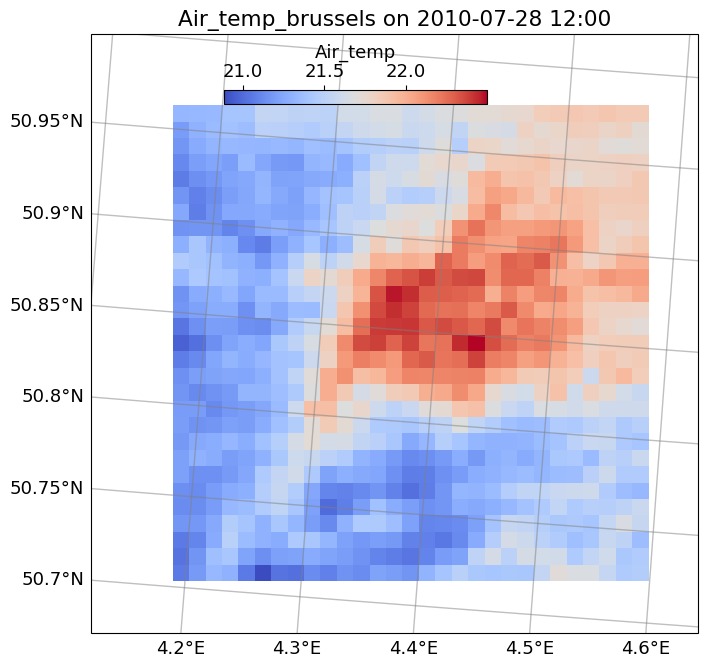

In [10]:
item = 0 #0=Air_temp, 1=RH, 2=Wind
folder = ['Air_temp_brussels', 'Relative_humidity_brussels', 'Wind_speed_brussels']
file = ['tas', 'russ', 'sfcWind']
output = ['Air_temp', 'RH', 'Wind']

year = 2010
# Define the starting date and time
start_datetime = dt.datetime(year, 1, 1, 0, 0)
ncfile5 = nc.Dataset('./data/Meteorology/Brussels/'+folder[item]+'/'+output[item]+'_brussels_' + str(year) + '.nc', "r", format="NETCDF4")
step = 5004
# Extract the latitude and longitude coordinates from the file
end_datetime = start_datetime + dt.timedelta(hours=step)
print(end_datetime)
print(ncfile5.variables[file[item]][1,16,5].data - 273.15)
if item == 0:
    data = ncfile5.variables[file[item]][step,::].data - 273.15
else:
    data = ncfile5.variables[file[item]][step,::].data
lons = ncfile5.variables['longitude'][:]
lats = ncfile5.variables['latitude'][:]
x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]
extent_3035 = [y.min()-500, y.max()+500, x.min()-500, x.max()+500 ]

# Create a plot with the correct coordinate system
plt.figure(figsize=(8.48, 9.15))
plt.rcParams.update({'font.size': 13})
ax = plt.axes(projection=ccrs.epsg(3035))
#y = y[::-1]
# Plot the data using pcolormesh
plt.pcolormesh(x, y, data, cmap='coolwarm')
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Set plot title
plt.title(folder[item] + ' on '+str(end_datetime)[0:-3])

# Show the plot
plt.colorbar(label=output[item], location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.75))

plt.show()

# Close the NetCDF file
ncfile5.close()

2011-07-28 08:00:00


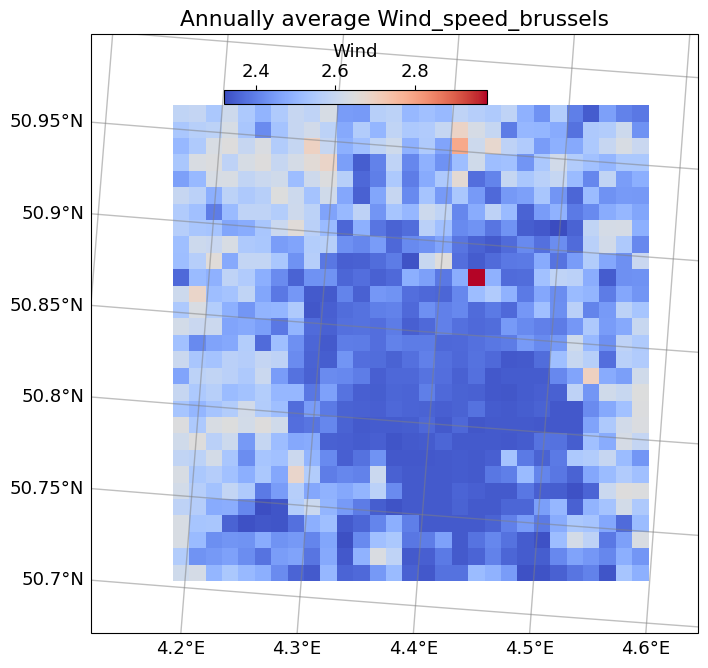

In [21]:
#show yearly average
year = 2011
# Define the starting date and time
start_datetime = dt.datetime(year, 1, 1, 0, 0)
ncfile5 = nc.Dataset('./data/Meteorology/Brussels/'+folder[item]+'/'+output[item]+'_brussels_' + str(year) + '.nc', "r", format="NETCDF4")

# Extract the latitude and longitude coordinates from the file
end_datetime = start_datetime + dt.timedelta(hours=step)
print(end_datetime)
data = ncfile5.variables[file[item]][::].data
lons = ncfile5.variables['longitude'][:]
lats = ncfile5.variables['latitude'][:]
x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]
extent_3035 = [y.min()-500, y.max()+500, x.min()-500, x.max()+500 ]

# Create a plot with the correct coordinate system
plt.figure(figsize=(8.48, 9.15))
plt.rcParams.update({'font.size': 13})
ax = plt.axes(projection=ccrs.epsg(3035))
#y = y[::-1]
# Plot the data using pcolormesh
plt.pcolormesh(x, y, np.mean(data, axis=0), cmap='coolwarm')
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Set plot title
plt.title('Annually average '+folder[item] )

# Show the plot
plt.colorbar(label=output[item], location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.75))

plt.show()

# Close the NetCDF file
ncfile5.close()

In [16]:
ncfile5 = netCDF4.Dataset('./data/Meteorology/Brussels/ruralurbanmask_Brussels_UrbClim_v1.0.nc',mode='r',format='NETCDF4_CLASSIC') 
print(ncfile5.variables)

{'x': <class 'netCDF4._netCDF4.Variable'>
float32 x(x)
    long_name: x-coordinate
    units: m
    axis: East-West
    crs: EPSG:3035 (ETRS89 / LAEA Europe)
unlimited dimensions: 
current shape = (301,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'y': <class 'netCDF4._netCDF4.Variable'>
float32 y(y)
    long_name: y-coordinate
    units: m
    axis: North-South
    crs: EPSG:3035 (ETRS89 / LAEA Europe)
unlimited dimensions: 
current shape = (301,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'latitude': <class 'netCDF4._netCDF4.Variable'>
float32 latitude(y, x)
    standard_name: latitude
    units: degrees_north
    crs: EPSG:4326 (WGS84)
unlimited dimensions: 
current shape = (301, 301)
filling on, default _FillValue of 9.969209968386869e+36 used, 'longitude': <class 'netCDF4._netCDF4.Variable'>
float32 longitude(y, x)
    standard_name: longitude
    units: degrees_east
    crs: EPSG:4326 (WGS84)
unlimited dimensions: 
current shape = (301, 301)
f

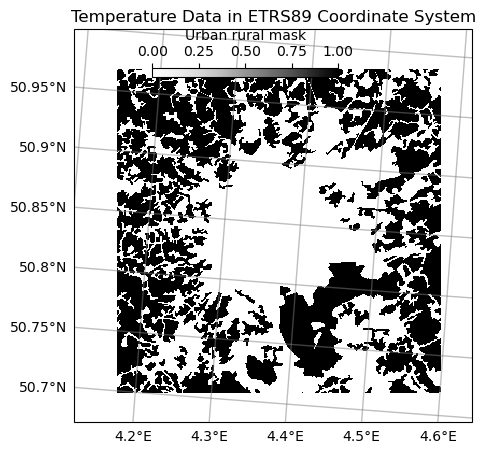

In [20]:
ncfile5 = netCDF4.Dataset('./data/Meteorology/Brussels/ruralurbanmask_Brussels_UrbClim_v1.0.nc',mode='r',format='NETCDF4_CLASSIC') 

# Extract the latitude, longitude, and temperature data from the file
lons = ncfile5.variables['longitude'][:]
lats = ncfile5.variables['latitude'][:]
data = ncfile5.variables['ruralurbanmask'][:]
x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]

# Create a plot with the correct coordinate system
plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.epsg(3035))

# Plot the data using pcolormesh
plt.pcolormesh(x, y, data, cmap='Grays',vmin = 0, vmax = 1)
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Set plot title
plt.title('Temperature Data in ETRS89 Coordinate System')

# Show the plot
plt.colorbar(label='Urban rural mask',location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.8))

plt.show()

# Close the NetCDF file
ncfile5.close()

In [18]:
ncfile5 = netCDF4.Dataset('./data/Meteorology/Brussels/landseamask_Brussels_UrbClim_v1.0.nc',mode='r',format='NETCDF4_CLASSIC') 
print(ncfile5.variables)

{'x': <class 'netCDF4._netCDF4.Variable'>
float32 x(x)
    long_name: x-coordinate
    units: m
    axis: East-West
    crs: EPSG:3035 (ETRS89 / LAEA Europe)
unlimited dimensions: 
current shape = (301,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'y': <class 'netCDF4._netCDF4.Variable'>
float32 y(y)
    long_name: y-coordinate
    units: m
    axis: North-South
    crs: EPSG:3035 (ETRS89 / LAEA Europe)
unlimited dimensions: 
current shape = (301,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'latitude': <class 'netCDF4._netCDF4.Variable'>
float32 latitude(y, x)
    standard_name: latitude
    units: degrees_north
    crs: EPSG:4326 (WGS84)
unlimited dimensions: 
current shape = (301, 301)
filling on, default _FillValue of 9.969209968386869e+36 used, 'longitude': <class 'netCDF4._netCDF4.Variable'>
float32 longitude(y, x)
    standard_name: longitude
    units: degrees_east
    crs: EPSG:4326 (WGS84)
unlimited dimensions: 
current shape = (301, 301)
f

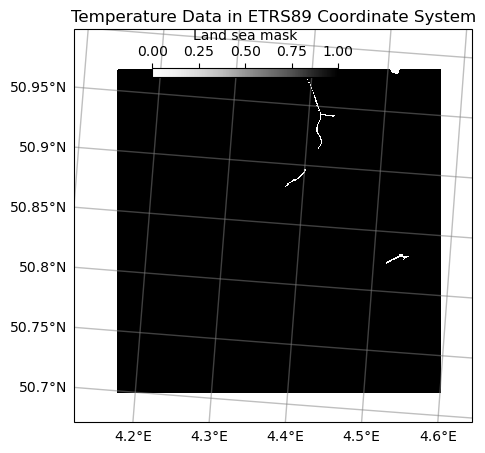

In [21]:
ncfile5 = netCDF4.Dataset('./data/Meteorology/Brussels/landseamask_Brussels_UrbClim_v1.0.nc',mode='r',format='NETCDF4_CLASSIC') 

# Extract the latitude, longitude, and temperature data from the file
lons = ncfile5.variables['longitude'][:]
lats = ncfile5.variables['latitude'][:]
data = ncfile5.variables['landseamask'][:]
x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]

# Create a plot with the correct coordinate system
plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.epsg(3035))

# Plot the data using pcolormesh
plt.pcolormesh(x, y, data, cmap='Grays',vmin = 0, vmax = 1)
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Set plot title
plt.title('Temperature Data in ETRS89 Coordinate System')

# Show the plot
plt.colorbar(label='Land sea mask',location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.8))

plt.show()

# Close the NetCDF file
ncfile5.close()